Get averages for times of day

In [1]:
#read in relevant packages
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyproj #for utm
#pyproj.datadir.get_data_dir()
pyproj.datadir.set_data_dir('C:\\Users\\rpkamakura\\AppData\\Local\\anaconda3\\envs\\wrf\\Library\\share\\proj') #should be whatever env you're using
#to make sure you can see the env: https://stackoverflow.com/questions/53004311/how-to-add-conda-environment-to-jupyter-lab 
import math #for distances

from netCDF4 import Dataset #for using wrf.getvar
from scipy.spatial import cKDTree

##dates
import datetime

#to get a list of the files in the folder
import glob 

##attempt to reformat the netcdf in one line
import xwrf

#to quickly calculate relative humidity
from wrf import getvar, interplevel, to_np, latlon_coords, uvmet
import wrf


Going to need to try to average at different time points to get an overall sense of the differences

Also want to actually store those values somewhere, with information on the land use and distance from the coast for each point

Then you can do a quick regression to see how the differences between the two time points (MHW - non) vary with land use and distance to the water, with pixel location as a random effect. Basically:

MHW temp ~ 1|pixel + land use + distance to water x time of day
nonMHW temp ~ 1|pixel + land use + distance to water x time of day

and see how those two compare?

Steps for this include:
* mask out the water
* acquire a representation of the coastline
* find the distance to this coastline for each pixel
* shift the dataframe to a row for each pixel at each hour time point with temperature as the value (and/or humidity)
* add the land use and distance to water as constants
* run the regression

Questions as doing so:
* should we average the pixel values at a given time of day across the days or just have each as an observation? If you average it, you would average out some of the noise in the data but would lose data points and would have less for the pixel random effect to capture. For the question you are asking, I lean towards averaging still by time of day
* Then would need to do that right before or after masking out the water

Resources:
* averaging: https://stackoverflow.com/questions/67868777/averaging-multiple-netcdf4-files-with-python

In [2]:
##trying this with wrf-python instead to see if it makes it at all easier
d02_2016_names = glob.glob("../../01Data/Houston_MarineHeatWave_2016/wrfout_MarineHeatWave.d02.*")
#d02_2017_names = glob.glob("../../01Data/Houston_MarineHeatWave_2017/wrfout_MarineHeatWave.d02.*")
#d02_2017_climavg_names  = glob.glob("../../01Data/Houston_MarineHeatWave_2017_w16SST/wrfout_MarineHeatWave.d02.*")

##Ideally we want to ignore the first few days as spin up (maybe get rid of 2 days worth? Need to add that in here

#pull out the datasets
wrfin = [Dataset(f) for f in d02_2016_names[8:] ] #gives you two days of burn-in time I think
#wrfin = [Dataset(f) for f in d02_2017_names[8:] ] #gives you two days of burn-in time I think
#wrfin = [Dataset(f) for f in d02_2017_climavg_names[8:] ] #gives you two days of burn-in time I think

T2_data = wrf.getvar(wrfin, "T2", timeidx=wrf.ALL_TIMES)
rh2_data = wrf.getvar(wrfin, "rh2", timeidx=wrf.ALL_TIMES)
#Uwind_data = wrf.getvar(wrfin, "U", timeidx=wrf.ALL_TIMES)
#Vwind_data = wrf.getvar(wrfin, "V", timeidx=wrf.ALL_TIMES)

# Get grid-relative U and V
uv = getvar(wrfin, "uvmet", timeidx=wrf.ALL_TIMES) 
uv10m = getvar(wrfin, "uvmet10", timeidx=wrf.ALL_TIMES)

p = getvar(wrfin, "pressure", timeidx=wrf.ALL_TIMES)         # shape: (Time, bottom_top, south_north, west_east)
uv_850 = interplevel(uv, p, 850)
uv_700 = interplevel(uv, p, 700)
uv_500 = interplevel(uv, p, 500)

SW_data = wrf.getvar(wrfin, "SWDNB", timeidx=wrf.ALL_TIMES) #switching from SWDown
#have to manage the shortwave accumulation a bit differently here...

Okay now you have rotated U,V but you need to figure out how to turn it into hourly averages. May need to get each pressure level first

Need to figure out how to adjust the output of the different uv levels

In [ ]:
uv10m

In [3]:
##now get the average values for each hour
DatesList = T2_data.coords['Time'].values
HourList = []

#get the dates you need
for dt in DatesList:
    full = datetime.datetime.strptime(str(dt.astype('datetime64[D]')), "%Y-%m-%d")
    hrs = pd.Timestamp(dt)
    HourList.append(hrs.hour)


#Go thorugh and get the hour-level means
#there has to be a better way of doing this...
for h in list(range(0,24)):
    
    hr_pos = [index for index, element in enumerate(HourList) if element == h]
    rel_times = DatesList[hr_pos]
    subgroup_T2 = T2_data.sel(Time = rel_times) #get the data across days at that hour
    subgroup_rh2 = rh2_data.sel(Time = rel_times)

    #this appears not to be working properly, or at least somewhat in this area
    subgroup_uv10 = uv10m.sel(Time = rel_times)
    subgroup_uv850 = uv_850.sel(Time = rel_times)
    subgroup_uv700 = uv_700.sel(Time = rel_times)
    subgroup_uv500 = uv_500.sel(Time = rel_times)

    if h == 0:
        subgroup_sw = SW_data.sel(Time = rel_times[1:]) #skip the first hour where have no data
    else:
        subgroup_sw = SW_data.sel(Time = rel_times)
    
    #get the mean for each pixel
    subgroup_T2_mean = subgroup_T2.mean(dim = ['Time'])
    subgroup_rh2_mean = subgroup_rh2.mean(dim = ['Time'])
    subgroup_uv10_mean = subgroup_uv10.mean(dim = ['Time'])
    subgroup_uv850_mean = subgroup_uv850.mean(dim = ['Time'])
    subgroup_uv700_mean = subgroup_uv700.mean(dim = ['Time'])
    subgroup_uv500_mean = subgroup_uv500.mean(dim = ['Time'])
    subgroup_sw_mean = subgroup_sw.mean(dim = ['Time'])

    #this is hideous, has to be a better way to store the info before combining
    if h==0:
        d0_T2 = subgroup_T2_mean
        d0_rh2 = subgroup_rh2_mean
        d0_uv10 = subgroup_uv10_mean
        d0_uv850 = subgroup_uv850_mean
        d0_uv700 = subgroup_uv700_mean
        d0_uv500 = subgroup_uv500_mean
        d0_sw = subgroup_sw_mean
    elif h==1:
        d1_T2 = subgroup_T2_mean
        d1_rh2 = subgroup_rh2_mean
        d1_uv10 = subgroup_uv10_mean
        d1_uv850 = subgroup_uv850_mean
        d1_uv700 = subgroup_uv700_mean
        d1_uv500 = subgroup_uv500_mean
        d1_sw = subgroup_sw_mean
    elif h==2:
        d2_T2 = subgroup_T2_mean
        d2_rh2 = subgroup_rh2_mean
        d2_uv10 = subgroup_uv10_mean
        d2_uv850 = subgroup_uv850_mean
        d2_uv700 = subgroup_uv700_mean
        d2_uv500 = subgroup_uv500_mean
        d2_sw = subgroup_sw_mean
    elif h==3:
        d3_T2 = subgroup_T2_mean
        d3_rh2 = subgroup_rh2_mean
        d3_uv10 = subgroup_uv10_mean
        d3_uv850 = subgroup_uv850_mean
        d3_uv700 = subgroup_uv700_mean
        d3_uv500 = subgroup_uv500_mean
        d3_sw = subgroup_sw_mean
    elif h==4:
        d4_T2 = subgroup_T2_mean
        d4_rh2 = subgroup_rh2_mean
        d4_uv10 = subgroup_uv10_mean
        d4_uv850 = subgroup_uv850_mean
        d4_uv700 = subgroup_uv700_mean
        d4_uv500 = subgroup_uv500_mean
        d4_sw = subgroup_sw_mean
    elif h==5:
        d5_T2 = subgroup_T2_mean
        d5_rh2 = subgroup_rh2_mean
        d5_uv10 = subgroup_uv10_mean
        d5_uv850 = subgroup_uv850_mean
        d5_uv700 = subgroup_uv700_mean
        d5_uv500 = subgroup_uv500_mean
        d5_sw = subgroup_sw_mean
    elif h==6:
        d6_T2 = subgroup_T2_mean
        d6_rh2 = subgroup_rh2_mean
        d6_uv10 = subgroup_uv10_mean
        d6_uv850 = subgroup_uv850_mean
        d6_uv700 = subgroup_uv700_mean
        d6_uv500 = subgroup_uv500_mean
        d6_sw = subgroup_sw_mean
    elif h==7:
        d7_T2 = subgroup_T2_mean
        d7_rh2 = subgroup_rh2_mean
        d7_uv10 = subgroup_uv10_mean
        d7_uv850 = subgroup_uv850_mean
        d7_uv700 = subgroup_uv700_mean
        d7_uv500 = subgroup_uv500_mean
        d7_sw = subgroup_sw_mean
    elif h==8:
        d8_T2 = subgroup_T2_mean
        d8_rh2 = subgroup_rh2_mean
        d8_uv10 = subgroup_uv10_mean
        d8_uv850 = subgroup_uv850_mean
        d8_uv700 = subgroup_uv700_mean
        d8_uv500 = subgroup_uv500_mean
        d8_sw = subgroup_sw_mean
    elif h==9:
        d9_T2 = subgroup_T2_mean
        d9_rh2 = subgroup_rh2_mean
        d9_uv10 = subgroup_uv10_mean
        d9_uv850 = subgroup_uv850_mean
        d9_uv700 = subgroup_uv700_mean
        d9_uv500 = subgroup_uv500_mean
        d9_sw = subgroup_sw_mean
    elif h==10:
        d10_T2 = subgroup_T2_mean
        d10_rh2 = subgroup_rh2_mean
        d10_uv10 = subgroup_uv10_mean
        d10_uv850 = subgroup_uv850_mean
        d10_uv700 = subgroup_uv700_mean
        d10_uv500 = subgroup_uv500_mean
        d10_sw = subgroup_sw_mean
    elif h==11:
        d11_T2 = subgroup_T2_mean
        d11_rh2 = subgroup_rh2_mean
        d11_uv10 = subgroup_uv10_mean
        d11_uv850 = subgroup_uv850_mean
        d11_uv700 = subgroup_uv700_mean
        d11_uv500 = subgroup_uv500_mean
        d11_sw = subgroup_sw_mean
    elif h==12:
        d12_T2 = subgroup_T2_mean
        d12_rh2 = subgroup_rh2_mean
        d12_uv10 = subgroup_uv10_mean
        d12_uv850 = subgroup_uv850_mean
        d12_uv700 = subgroup_uv700_mean
        d12_uv500 = subgroup_uv500_mean
        d12_sw = subgroup_sw_mean
    elif h==13:
        d13_T2 = subgroup_T2_mean
        d13_rh2 = subgroup_rh2_mean
        d13_uv10 = subgroup_uv10_mean
        d13_uv850 = subgroup_uv850_mean
        d13_uv700 = subgroup_uv700_mean
        d13_uv500 = subgroup_uv500_mean
        d13_sw = subgroup_sw_mean
    elif h==14:
        d14_T2 = subgroup_T2_mean
        d14_rh2 = subgroup_rh2_mean
        d14_uv10 = subgroup_uv10_mean
        d14_uv850 = subgroup_uv850_mean
        d14_uv700 = subgroup_uv700_mean
        d14_uv500 = subgroup_uv500_mean
        d14_sw = subgroup_sw_mean
    elif h==15:
        d15_T2 = subgroup_T2_mean
        d15_rh2 = subgroup_rh2_mean
        d15_uv10 = subgroup_uv10_mean
        d15_uv850 = subgroup_uv850_mean
        d15_uv700 = subgroup_uv700_mean
        d15_uv500 = subgroup_uv500_mean
        d15_sw = subgroup_sw_mean
    elif h==16:
        d16_T2 = subgroup_T2_mean
        d16_rh2 = subgroup_rh2_mean
        d16_uv10 = subgroup_uv10_mean
        d16_uv850 = subgroup_uv850_mean
        d16_uv700 = subgroup_uv700_mean
        d16_uv500 = subgroup_uv500_mean
        d16_sw = subgroup_sw_mean
    elif h==17:
        d17_T2 = subgroup_T2_mean
        d17_rh2 = subgroup_rh2_mean
        d17_uv10 = subgroup_uv10_mean
        d17_uv850 = subgroup_uv850_mean
        d17_uv700 = subgroup_uv700_mean
        d17_uv500 = subgroup_uv500_mean
        d17_sw = subgroup_sw_mean
    elif h==18:
        d18_T2 = subgroup_T2_mean
        d18_rh2 = subgroup_rh2_mean
        d18_uv10 = subgroup_uv10_mean
        d18_uv850 = subgroup_uv850_mean
        d18_uv700 = subgroup_uv700_mean
        d18_uv500 = subgroup_uv500_mean
        d18_sw = subgroup_sw_mean
    elif h==19:
        d19_T2 = subgroup_T2_mean
        d19_rh2 = subgroup_rh2_mean
        d19_uv10 = subgroup_uv10_mean
        d19_uv850 = subgroup_uv850_mean
        d19_uv700 = subgroup_uv700_mean
        d19_uv500 = subgroup_uv500_mean
        d19_sw = subgroup_sw_mean
    elif h==20:
        d20_T2 = subgroup_T2_mean
        d20_rh2 = subgroup_rh2_mean
        d20_uv10 = subgroup_uv10_mean
        d20_uv850 = subgroup_uv850_mean
        d20_uv700 = subgroup_uv700_mean
        d20_uv500 = subgroup_uv500_mean
        d20_sw = subgroup_sw_mean
    elif h==21:
        d21_T2 = subgroup_T2_mean
        d21_rh2 = subgroup_rh2_mean
        d21_uv10 = subgroup_uv10_mean
        d21_uv850 = subgroup_uv850_mean
        d21_uv700 = subgroup_uv700_mean
        d21_uv500 = subgroup_uv500_mean
        d21_sw = subgroup_sw_mean
    elif h==22:
        d22_T2 = subgroup_T2_mean
        d22_rh2 = subgroup_rh2_mean
        d22_uv10 = subgroup_uv10_mean
        d22_uv850 = subgroup_uv850_mean
        d22_uv700 = subgroup_uv700_mean
        d22_uv500 = subgroup_uv500_mean
        d22_sw = subgroup_sw_mean
    elif h==23:
        d23_T2 = subgroup_T2_mean
        d23_rh2 = subgroup_rh2_mean
        d23_uv10 = subgroup_uv10_mean
        d23_uv850 = subgroup_uv850_mean
        d23_uv700 = subgroup_uv700_mean
        d23_uv500 = subgroup_uv500_mean
        d23_sw = subgroup_sw_mean


#I think you have to do this at the end - or at least have not figured out how to avoid it rn
HourlyXYMeans_2mTemp = xr.concat([d0_T2, d1_T2, d2_T2, d3_T2, d4_T2, d5_T2, d6_T2, d7_T2, 
                                  d8_T2, d9_T2, d10_T2, d11_T2, d12_T2, d13_T2, d14_T2, 
                                  d15_T2, d16_T2, d17_T2, d18_T2, d19_T2, d20_T2, d21_T2, 
                                  d22_T2, d23_T2], 
                                 pd.Index(list(range(0,24)), name='hour'))
HourlyXYMeans_RelHum = xr.concat([d0_rh2, d1_rh2, d2_rh2, d3_rh2, d4_rh2, d5_rh2, d6_rh2, 
                                  d7_rh2, d8_rh2, d9_rh2, d10_rh2, d11_rh2, d12_rh2, d13_rh2, 
                                  d14_rh2, d15_rh2, d16_rh2, d17_rh2, d18_rh2, d19_rh2, 
                                  d20_rh2, d21_rh2, d22_rh2, d23_rh2], 
                                 pd.Index(list(range(0,24)), name='hour'))

HourlyXYMeans_UV10 = xr.concat([d0_uv10, d1_uv10, d2_uv10, d3_uv10, d4_uv10, d5_uv10, d6_uv10, d7_uv10, 
                                  d8_uv10, d9_uv10, d10_uv10, d11_uv10, d12_uv10, d13_uv10, d14_uv10, 
                                  d15_uv10, d16_uv10, d17_uv10, d18_uv10, d19_uv10, d20_uv10, d21_uv10, 
                                  d22_uv10, d23_uv10], 
                                 pd.Index(list(range(0,24)), name='hour'))

HourlyXYMeans_uv850 = xr.concat([d0_uv850, d1_uv850, d2_uv850, d3_uv850, d4_uv850, d5_uv850, d6_uv850, d7_uv850, 
                                  d8_uv850, d9_uv850, d10_uv850, d11_uv850, d12_uv850, d13_uv850, d14_uv850, 
                                  d15_uv850, d16_uv850, d17_uv850, d18_uv850, d19_uv850, d20_uv850, d21_uv850, 
                                  d22_uv850, d23_uv850], 
                                 pd.Index(list(range(0,24)), name='hour'))
HourlyXYMeans_uv700 = xr.concat([d0_uv700, d1_uv700, d2_uv700, d3_uv700, d4_uv700, d5_uv700, d6_uv700, d7_uv700, 
                                  d8_uv700, d9_uv700, d10_uv700, d11_uv700, d12_uv700, d13_uv700, d14_uv700, 
                                  d15_uv700, d16_uv700, d17_uv700, d18_uv700, d19_uv700, d20_uv700, d21_uv700, 
                                  d22_uv700, d23_uv700], 
                                 pd.Index(list(range(0,24)), name='hour'))
HourlyXYMeans_uv500 = xr.concat([d0_uv500, d1_uv500, d2_uv500, d3_uv500, d4_uv500, d5_uv500, d6_uv500, d7_uv500, 
                                  d8_uv500, d9_uv500, d10_uv500, d11_uv500, d12_uv500, d13_uv500, d14_uv500, 
                                  d15_uv500, d16_uv500, d17_uv500, d18_uv500, d19_uv500, d20_uv500, d21_uv500, 
                                  d22_uv500, d23_uv500], 
                                 pd.Index(list(range(0,24)), name='hour'))


HourlyXYMeans_SW = xr.concat([d0_sw, d1_sw, d2_sw, d3_sw, d4_sw, d5_sw, d6_sw, d7_sw, 
                                  d8_sw, d9_sw, d10_sw, d11_sw, d12_sw, d13_sw, d14_sw, 
                                  d15_sw, d16_sw, d17_sw, d18_sw, d19_sw, d20_sw, d21_sw, 
                                  d22_sw, d23_sw], 
                                 pd.Index(list(range(0,24)), name='hour'))

        
#HourlyXYMeans_2mTemp #to see if it works and look at attributes

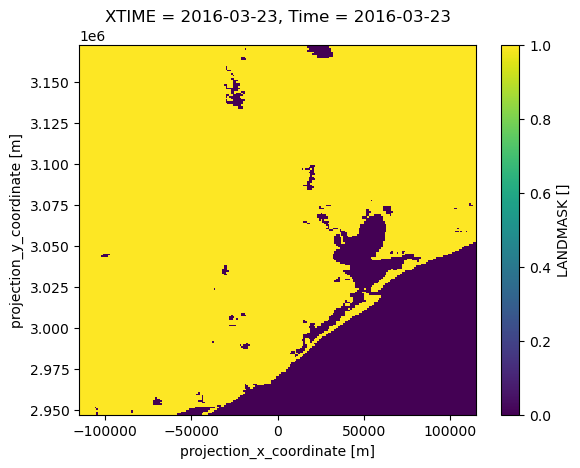

In [4]:
##figure out the coastline to do distance to coastline
#https://stackoverflow.com/questions/45440700/calculate-distance-to-shore-or-coastline-for-a-vessel
#https://gis.stackexchange.com/questions/99755/how-to-find-the-distance-to-the-nearest-coastline-from-a-land-based-latitude-lon
#might want to use cdist from scipy.spatial.distance or np.min to find minimum distance

#get just one time period
initial_ds = xr.open_dataset(d02_2016_names[0]).xwrf.postprocess()
#initial_ds = xr.open_dataset(d02_2017_names[0]).xwrf.postprocess()
#initial_ds = xr.open_dataset(d02_2017_climavg_names[0]).xwrf.postprocess()

init_ds = initial_ds.isel(Time=0)

#maybe pull LANDMASK to get the water vs land coordinates
#the grid cells should all be the same so can just use the initial run
overall_Landsmask = init_ds.LANDMASK

fig = plt.figure()
overall_Landsmask.plot.imshow()

#so need to then include the lakes as part of the land
lakes = init_ds.LAKEMASK

#fig = plt.figure()
#lakes.plot.imshow()

In [11]:
init_ds

<xarray.Dataset> Size: 233MB
Dimensions:                    (y: 225, x: 230, soil_layers_stag: 4, z: 44,
                                x_stag: 231, y_stag: 226, z_stag: 45,
                                seed_dim_stag: 8)
Coordinates: (12/15)
    XLAT                       (y, x) float32 207kB 28.71 28.71 ... 30.69 30.69
    XLONG                      (y, x) float32 207kB -96.51 -96.5 ... -94.18
    XTIME                      datetime64[ns] 8B 2017-03-23
    XLAT_U                     (y, x_stag) float32 208kB 28.71 28.71 ... 30.69
    XLONG_U                    (y, x_stag) float32 208kB -96.51 -96.5 ... -94.17
    XLAT_V                     (y_stag, x) float32 208kB 28.7 28.7 ... 30.69
    ...                         ...
  * z_stag                     (z_stag) float32 180B 1.0 0.9946 ... 0.0056 0.0
    Time                       datetime64[ns] 8B 2017-03-23
  * y                          (y) float64 2kB 2.948e+06 2.949e+06 ... 3.172e+06
  * y_stag                     (y_stag) float64 2kB 2.947e+06 ... 3.172e+06
  * x                          (x) float64 2kB -1.145e+05 ... 1.145e+05
  * x_stag                     (x_stag) float64 2kB -1.15e+05 ... 1.15e+05
Dimensions without coordinates: soil_layers_stag, seed_dim_stag
Data variables: (12/212)
    Times                      |S19 19B b'2017-03-23_00:00:00'
    LU_INDEX                   (y, x) float32 207kB ...
    ZS                         (soil_layers_stag) float32 16B ...
    DZS                        (soil_layers_stag) float32 16B ...
    VAR_SSO                    (y, x) float32 207kB ...
    BATHYMETRY_FLAG            int32 4B ...
    ...                         ...
    geopotential_height        (z_stag, y, x) float32 9MB 9.33 ... 2.054e+04
    wind_east                  (z, y, x) float32 9MB -2.041 -2.031 ... -4.17
    wind_north                 (z, y, x) float32 9MB 5.228 5.215 ... -3.38
    wind_east_10               (y, x) float32 207kB -1.886 -1.882 ... -0.102
    wind_north_10              (y, x) float32 207kB 4.721 4.725 ... 2.438 2.443
    wrf_projection             object 8B +proj=merc +x_0=0 +y_0=0 +a=6370000 ...
Attributes: (12/136)
    TITLE:                            OUTPUT FROM WRF V4.6.0 MODEL
    START_DATE:                      2017-03-23_00:00:00
    SIMULATION_START_DATE:           2017-03-23_00:00:00
    WEST-EAST_GRID_DIMENSION:        231
    SOUTH-NORTH_GRID_DIMENSION:      226
    BOTTOM-TOP_GRID_DIMENSION:       45
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

In [5]:
#this is effectively an actual ocean mask
nonOcean = overall_Landsmask + lakes

#now can create two dfs that have nans either where there is ocean or where there is land
nonOcean_wnan = nonOcean.where(nonOcean.values == 1)
Ocean_wnan = nonOcean.where(nonOcean.values == 0)

##try to figure out closest distance to ocean for each land point

Ocean_lats = Ocean_wnan.coords['XLAT'].values
Ocean_lons = Ocean_wnan.coords['XLONG'].values

#I think should be able to select the coordinates this way???
Ocean_indices = np.isnan(nonOcean_wnan.values)

#do the selection and should have pairs of each
Ocean_lats_nn = Ocean_lats[Ocean_indices]
Ocean_lons_nn = Ocean_lons[Ocean_indices]

##now do the same for the land points
nonOcean_lats = nonOcean_wnan.coords['XLAT'].values
nonOcean_lons = nonOcean_wnan.coords['XLONG'].values

#I think should be able to select the coordinates this way???
nonOcean_indices = np.isnan(Ocean_wnan.values)

#do the selection and should have pairs of each
nonOcean_lats_nn = nonOcean_lats[nonOcean_indices]
nonOcean_lons_nn = nonOcean_lons[nonOcean_indices]

##land use - a predictor
landuse = initial_ds.LU_INDEX


In [6]:
#initialize your df
nn = 41967
#nn = 41956


nrows=nn*24
ncols = 16
column_names = ['GridCell', 'lat', 'long', 'hour', '2mTemp', 'RelHumid', 'UWind_10m', 'VWind_10m',
                'UWind_850hpa', 'VWind_850hpa', 'UWind_700hpa', 'VWind_700hpa','UWind_500hpa', 'VWind_500hpa',
                'SWDown', 'LandUse']
HourlyMeans_arr = np.zeros((nrows, ncols))

#this is not quite right, need each to be repeated 24 times (for each hour of the day)
HourlyMeans_arr[:,0] = list(range(1,(nn+1)))*24

HourlyMeans_arr[:,1] = [item for _ in range(24) for item in nonOcean_lats_nn]
HourlyMeans_arr[:,2] = [item for _ in range(24) for item in nonOcean_lons_nn]

#have to go extract the coordinates of this weird 2D coordinate array system to deal with indexing later
#latitudes = HourlyXYMeans_2mTemp.coords['south_north'].values
#longitudes = HourlyXYMeans_2mTemp.coords['west_east'].values

#alternative to consider: https://wrf-python.readthedocs.io/en/latest/basic_usage.html#example-using-lat-lon-coordinates

#for each hour
iter = 0
for h in list(range(0,24)):

    #h index is easy, they are in numerical order
    
    for p in list(range(0,nn)):
        #go through and get the lat/lon
        plat=nonOcean_lats_nn[p]
        plon=nonOcean_lons_nn[p]

        #https://forum.mmm.ucar.edu/threads/please-help-wrf-python-data-extraction-at-specific-lat-and-lon-position.20350/
        x_y = wrf.ll_to_xy(wrfin, plat, plon, as_int=True)
    
        #get the 2m temps at that lat/lon at that hour
        #I don't think this works correctly
        #lat_idx = (np.abs(latitudes - plat)).argmin()
        #lon_idx = (np.abs(longitudes - plon)).argmin()
        
        temp2m = HourlyXYMeans_2mTemp[h, x_y[1], x_y[0]]
        rh2m = HourlyXYMeans_RelHum[h, x_y[1], x_y[0]]
        u_10 = HourlyXYMeans_UV10[h, 0, x_y[1], x_y[0]] #this should be not quite the lowest but the second-lowest atmospheric level (out of 44) 
        v_10 = HourlyXYMeans_UV10[h, 1, x_y[1], x_y[0]] #this should be not quite the lowest but the second-lowest atmospheric level (out of 44)

        u_850 = HourlyXYMeans_uv850[h, 0, x_y[1], x_y[0]] #this should be not quite the lowest but the third-lowest atmospheric level (out of 44) 
        v_850 = HourlyXYMeans_uv850[h, 1, x_y[1], x_y[0]] #this should be not quite the lowest but the third-lowest atmospheric level (out of 44)

        u_700 = HourlyXYMeans_uv700[h, 0, x_y[1], x_y[0]] #low-middle
        v_700 = HourlyXYMeans_uv700[h, 1, x_y[1], x_y[0]] #low-middle

        u_500 = HourlyXYMeans_uv500[h, 0, x_y[1], x_y[0]] #middle
        v_500 = HourlyXYMeans_uv500[h, 1, x_y[1], x_y[0]] #middle
        
        sw = HourlyXYMeans_SW[h, x_y[1], x_y[0]]
        
        lu = landuse[0, x_y[1], x_y[0]]
        #lu = landuse.isel(y=lat_idx, x=lon_idx, Time=0)
        #rh2m = HourlyXYMeans_RelHum.isel(XLAT=plat, XLONG=plon, hour=h)
        #rh2m = HourlyXYMeans_RelHum.isel(south_north=lat_idx, west_east=lon_idx, hour=h)

        #add that value to the df
        HourlyMeans_arr[iter,3] = h
        HourlyMeans_arr[iter,4] = temp2m
        HourlyMeans_arr[iter,5] = rh2m
        
        #add all the wind information
        HourlyMeans_arr[iter,6] = u_10
        HourlyMeans_arr[iter,7] = v_10
        HourlyMeans_arr[iter,8] = u_850
        HourlyMeans_arr[iter,9] = v_850
        HourlyMeans_arr[iter,10] = u_700
        HourlyMeans_arr[iter,11] = v_700
        HourlyMeans_arr[iter,12] = u_500
        HourlyMeans_arr[iter,13] = v_500

        #add the last ones
        HourlyMeans_arr[iter,14] = sw
        HourlyMeans_arr[iter,15] = lu

        #increase iter
        iter += 1


In [7]:
#once ready
HourlyMeans_df = pd.DataFrame(HourlyMeans_arr, columns=column_names)

HourlyMeans_df.to_csv('../../03ProcessedData/HourlyMeans_2016_052725.csv', index=False)
#HourlyMeans_df.to_csv('../../03ProcessedData/HourlyMeans_2017_052725.csv', index=False)
#HourlyMeans_df.to_csv('../../03ProcessedData/HourlyMeans_2017_w16SST_052725.csv', index=False)